Loading Donut model (first run will download weights)...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model loaded on cpu

=== Donut Document Understanding ===

Q: What are all the fillable input fields in this form?
A: waterful walting

Q: What checkboxes are present in this form?
A: vertically undergoing or has completed

Q: What underline fields require user input such as name or signature?
A: the veteran have any complications or residuals of treatment requiring transfusion of platelets or red blood cells

=== Visual Detection (OpenCV) ===
  Checkboxes  : 62
  Input lines : 15


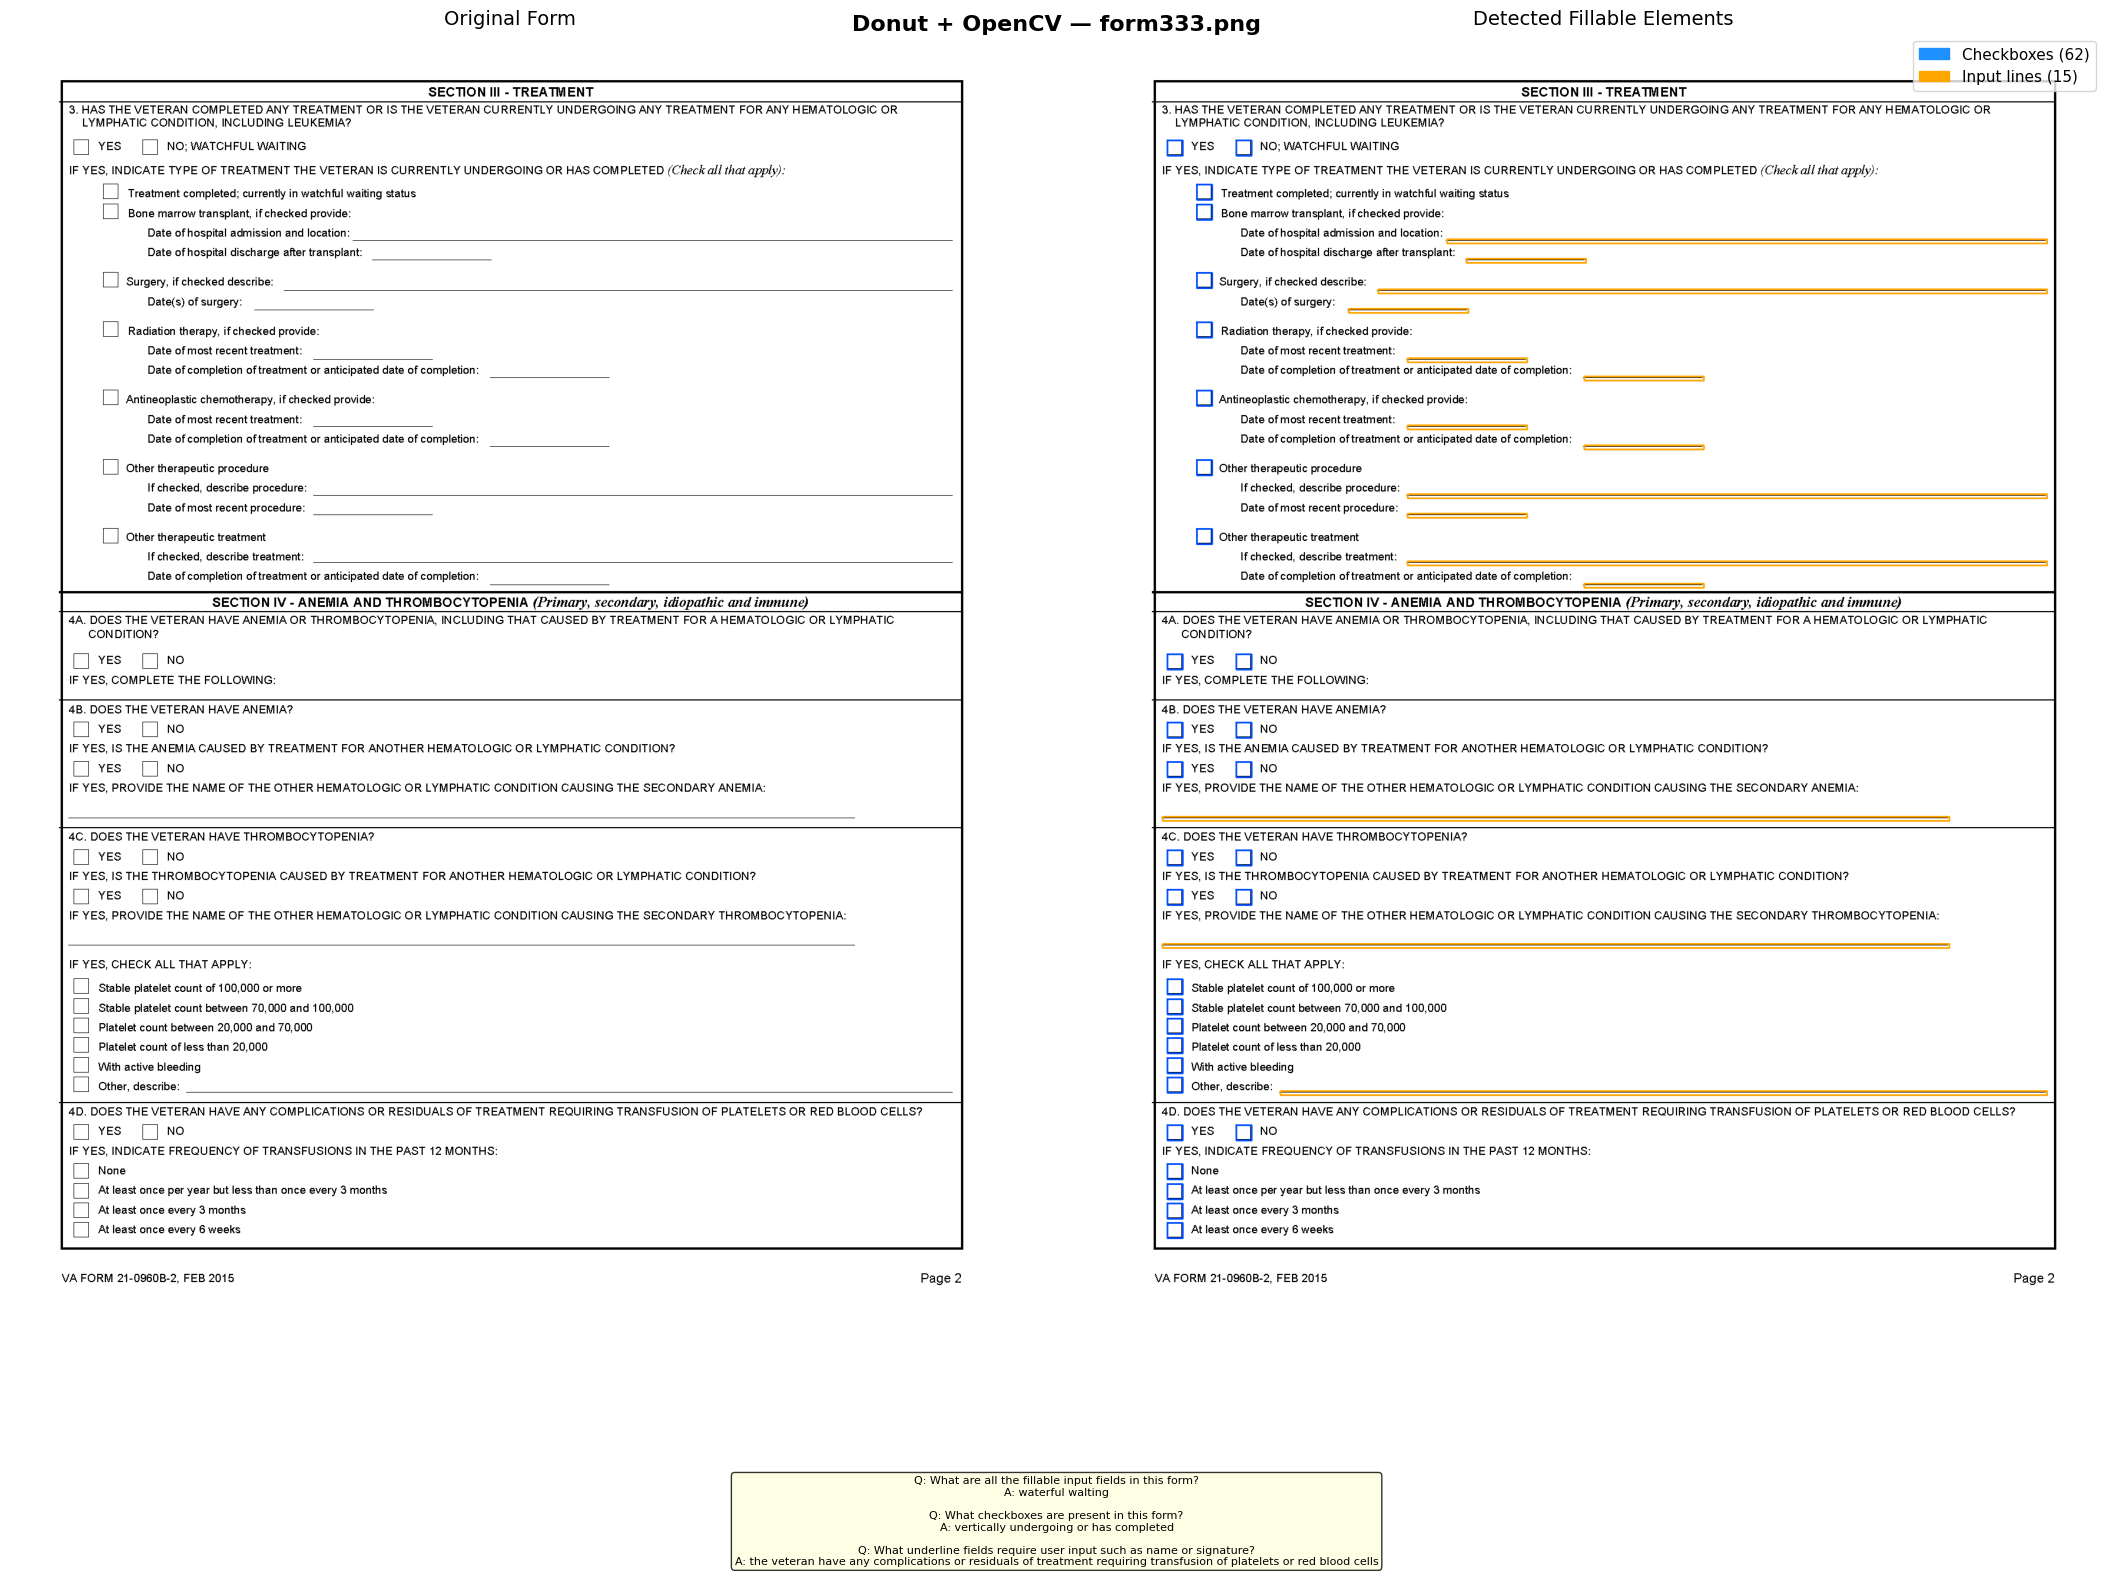


Annotated image saved → detected_fields_donut.png


In [2]:
import os
import re
import json
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import DonutProcessor, VisionEncoderDecoderModel
import torch

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
DATA_FOLDER = os.path.join(os.path.dirname("*"), "data")
IMAGE_NAME  = "form333.png"          # ← change to any form image
IMAGE_PATH  = os.path.join(DATA_FOLDER, IMAGE_NAME)

MODEL_ID    = "naver-clova-ix/donut-base-finetuned-docvqa"

# ─────────────────────────────────────────────
# LOAD DONUT
# ─────────────────────────────────────────────

def load_model():
    print("Loading Donut model (first run will download weights)...")
    processor = DonutProcessor.from_pretrained(MODEL_ID)
    model     = VisionEncoderDecoderModel.from_pretrained(MODEL_ID)
    device    = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()
    print(f"Model loaded on {device}")
    return processor, model, device

# ─────────────────────────────────────────────
# DONUT INFERENCE — ask about the form
# ─────────────────────────────────────────────

QUESTIONS = [
    "What are all the fillable input fields in this form?",
    "What checkboxes are present in this form?",
    "What underline fields require user input such as name or signature?",
]

def ask_donut(image: Image.Image, question: str, processor, model, device) -> str:
    task_prompt = f"<s_docvqa><s_question>{question}</s_question><s_answer>"
    decoder_input_ids = processor.tokenizer(
        task_prompt, add_special_tokens=False, return_tensors="pt"
    ).input_ids

    pixel_values = processor(image.convert("RGB"), return_tensors="pt").pixel_values

    with torch.no_grad():
        outputs = model.generate(
            pixel_values.to(device),
            decoder_input_ids=decoder_input_ids.to(device),
            max_length=512,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
            bad_words_ids=[[processor.tokenizer.unk_token_id]],
            return_dict_in_generate=True,
        )

    sequence = processor.batch_decode(outputs.sequences)[0]
    # Strip special tokens and task prompt wrapper
    sequence = sequence.replace(processor.tokenizer.eos_token, "")
    sequence = sequence.replace(processor.tokenizer.pad_token, "")
    sequence = re.sub(r"<s_docvqa>.*?<s_answer>", "", sequence, flags=re.DOTALL).strip()
    sequence = re.sub(r"</s_answer>", "", sequence).strip()
    return sequence

# ─────────────────────────────────────────────
# FALLBACK: OpenCV for visual bounding boxes
# Since Donut outputs text (not pixel coords),
# we use CV to draw boxes — Donut drives WHAT,
# CV drives WHERE.
# ─────────────────────────────────────────────

def load_cv_image(path):
    img_pil = Image.open(path).convert("L")
    return np.array(img_pil)

def preprocess(gray):
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    return cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

def detect_checkboxes(binary, img_w, img_h):
    CHECKBOX_MIN, CHECKBOX_MAX, SQUARE_TOL = 10, 50, 0.30
    contours, _ = cv2.findContours(binary, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for cnt in contours:
        peri   = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
        if len(approx) != 4:
            continue
        x, y, w, h = cv2.boundingRect(approx)
        if w > img_w * 0.95 or h > img_h * 0.95:
            continue
        if (CHECKBOX_MIN <= w <= CHECKBOX_MAX and
                CHECKBOX_MIN <= h <= CHECKBOX_MAX and
                abs(1 - w / h) <= SQUARE_TOL):
            boxes.append((x, y, w, h))
    return boxes

def detect_input_lines(binary, checkboxes):
    LINE_MIN_W, LINE_MAX_H = 100, 4
    LABEL_SEARCH, LABEL_RATIO, VICINITY = 300, 0.01, 20

    kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    h_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(h_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    lines = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w < LINE_MIN_W or h > LINE_MAX_H:
            continue
        # label check
        lx1 = max(0, x - LABEL_SEARCH)
        lx2 = max(0, x - 5)
        ly1, ly2 = max(0, y - 10), min(binary.shape[0], y + h + 10)
        if lx2 <= lx1:
            continue
        region = binary[ly1:ly2, lx1:lx2]
        if region.size == 0 or np.count_nonzero(region) / region.size <= LABEL_RATIO:
            continue
        # vicinity of checkbox check
        if any(x >= cx - VICINITY and x + w <= cx + cw + VICINITY and
               y >= cy - VICINITY and y + h <= cy + ch + VICINITY
               for (cx, cy, cw, ch) in checkboxes):
            continue
        lines.append((x, y, w, h))
    return lines

def draw_results(gray, checkboxes, input_lines):
    vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    for (x, y, w, h) in checkboxes:
        cv2.rectangle(vis, (x, y), (x+w, y+h), (255, 80, 0), 2)
    for (x, y, w, h) in input_lines:
        cv2.rectangle(vis, (x, y-3), (x+w, y+h+3), (0, 165, 255), 2)
    return vis

# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def main():
    # ── Donut: semantic understanding ───────────
    processor, model, device = load_model()
    pil_image = Image.open(IMAGE_PATH)

    print("\n=== Donut Document Understanding ===")
    donut_results = {}
    for q in QUESTIONS:
        answer = ask_donut(pil_image, q, processor, model, device)
        donut_results[q] = answer
        print(f"\nQ: {q}")
        print(f"A: {answer}")

    # ── OpenCV: visual element location ─────────
    gray   = load_cv_image(IMAGE_PATH)
    h_img, w_img = gray.shape
    binary = preprocess(gray)

    checkboxes  = detect_checkboxes(binary, w_img, h_img)
    input_lines = detect_input_lines(binary, checkboxes)

    print(f"\n=== Visual Detection (OpenCV) ===")
    print(f"  Checkboxes  : {len(checkboxes)}")
    print(f"  Input lines : {len(input_lines)}")

    # ── Visualise ────────────────────────────────
    vis = draw_results(gray, checkboxes, input_lines)

    legend = [
        mpatches.Patch(color="dodgerblue", label=f"Checkboxes ({len(checkboxes)})"),
        mpatches.Patch(color="orange",     label=f"Input lines ({len(input_lines)})"),
    ]

    fig = plt.figure(figsize=(22, 16))

    # Original + annotated side by side
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(gray, cmap="gray")
    ax1.set_title("Original Form", fontsize=14)
    ax1.axis("off")

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax2.set_title("Detected Fillable Elements", fontsize=14)
    ax2.legend(handles=legend, loc="upper right", fontsize=11)
    ax2.axis("off")

    # Donut understanding printed below
    donut_text = "\n\n".join(
        f"Q: {q}\nA: {a}" for q, a in donut_results.items()
    )
    fig.text(0.5, 0.01, donut_text, ha="center", va="bottom",
             fontsize=8, wrap=True,
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

    plt.suptitle(f"Donut + OpenCV — {IMAGE_NAME}", fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0.15, 1, 1])
    plt.show()

    out_path = os.path.join(os.path.dirname("*"), "detected_fields_donut.png")
    cv2.imwrite(out_path, vis)
    print(f"\nAnnotated image saved → {out_path}")


if __name__ == "__main__":
    main()